# Replogle Pert UMAPs

This notebook loads the sampled `flow_predict` / `flow_true` AnnData files, selects several perturbations, and draws one UMAP per perturbation with `control`, `prediction`, and `ground truth` cells in the same embedding.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from IPython.display import Image, display

sc.settings.verbosity = 1
sc.set_figure_params(dpi=120, facecolor="white")

ANALYZE_DIR = Path("/home/zichong/fork/PerturbDiff/analyze")
SAMPLE_DIR = Path("/home/zichong/fork/PerturbDiff/checkpoints/test_samples/replogle_gaussian_flow_test_sampling")
PRED_PATH = SAMPLE_DIR / "flow_predict_20260409_192016.h5ad"
TRUE_PATH = SAMPLE_DIR / "flow_true_20260409_192016.h5ad"
OUTPUT_DIR = ANALYZE_DIR / "umap_plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N_PERTS = 6
SELECTED_PERTS = None
CONTROL_MAX_CELLS = 250
RANDOM_SEED = 0

PRED_PATH, TRUE_PATH, OUTPUT_DIR

(PosixPath('/home/zichong/fork/PerturbDiff/checkpoints/test_samples/replogle_gaussian_flow_test_sampling/flow_predict_20260409_192016.h5ad'),
 PosixPath('/home/zichong/fork/PerturbDiff/checkpoints/test_samples/replogle_gaussian_flow_test_sampling/flow_true_20260409_192016.h5ad'),
 PosixPath('/home/zichong/fork/PerturbDiff/analyze/umap_plots'))

In [ ]:
pred_adata = ad.read_h5ad(PRED_PATH)
true_adata = ad.read_h5ad(TRUE_PATH)

assert pred_adata.n_obs == true_adata.n_obs
assert pred_adata.n_vars == true_adata.n_vars
assert pred_adata.obs[["gene", "cell_line", "gem_group"]].equals(true_adata.obs[["gene", "cell_line", "gem_group"]])

control_mask = pred_adata.obs["gene"].eq("non-targeting")
control_adata = pred_adata[control_mask].copy()

pert_counts = (
    pred_adata.obs.loc[~control_mask, "gene"]
    .value_counts()
    .rename_axis("pert")
    .reset_index(name="n_cells")
)

selected_perts = SELECTED_PERTS or pert_counts.head(TOP_N_PERTS)["pert"].tolist()

print(f"pred shape: {pred_adata.shape}")
print(f"true shape: {true_adata.shape}")
print(f"control cells: {control_adata.n_obs}")
print(f"selected perts: {selected_perts}")
pert_counts.head(20)

pred shape: (31854, 2000)
true shape: (31854, 2000)
control cells: 4976
selected perts: ['PPP6C', 'ZDHHC7', 'CCDC6', 'SART3', 'MRPL35', 'SLU7']


,pert,n_cells
0,PPP6C,433
1,ZDHHC7,424
2,CCDC6,396
3,SART3,337
4,MRPL35,317
5,SLU7,290
6,GPS1,269
7,FBXO42,265
8,RABGGTA,240
9,TMEM214,236


: 

: 

: 

: 

: 

In [ ]:
PALETTE = {
    "control": "#9aa0a6",
    "prediction": "#d95f02",
    "ground_truth": "#1b9e77",
}


def _subsample_adata(adata: ad.AnnData, max_cells: int | None, seed: int) -> ad.AnnData:
    if max_cells is None or adata.n_obs <= max_cells:
        return adata.copy()
    rng = np.random.default_rng(seed)
    picked = np.sort(rng.choice(adata.n_obs, size=max_cells, replace=False))
    return adata[picked].copy()


def build_plot_adata(pert: str, control_max_cells: int = CONTROL_MAX_CELLS, seed: int = RANDOM_SEED) -> ad.AnnData:
    ctrl = _subsample_adata(control_adata, control_max_cells, seed)
    pred = pred_adata[pred_adata.obs["gene"].eq(pert)].copy()
    truth = true_adata[true_adata.obs["gene"].eq(pert)].copy()

    if pred.n_obs == 0 or truth.n_obs == 0:
        raise ValueError(f"No cells found for pert={pert}")

    merged = ad.concat(
        {"control": ctrl, "prediction": pred, "ground_truth": truth},
        label="source",
        index_unique="-",
        join="inner",
    )

    merged.X = np.asarray(merged.X, dtype=np.float32)
    sc.pp.scale(merged, max_value=10)

    n_comps = max(2, min(50, merged.n_obs - 1, merged.n_vars - 1))
    n_pcs = max(2, min(30, n_comps))
    n_neighbors = max(5, min(30, merged.n_obs - 1))

    sc.tl.pca(merged, svd_solver="arpack", n_comps=n_comps)
    sc.pp.neighbors(merged, n_neighbors=n_neighbors, n_pcs=n_pcs)
    sc.tl.umap(merged, random_state=seed)
    return merged


def plot_single_pert(pert: str, control_max_cells: int = CONTROL_MAX_CELLS, seed: int = RANDOM_SEED):
    plot_adata = build_plot_adata(pert, control_max_cells=control_max_cells, seed=seed)
    counts = plot_adata.obs["source"].value_counts()

    fig, ax = plt.subplots(figsize=(7, 6))
    sc.pl.umap(
        plot_adata,
        color="source",
        palette=PALETTE,
        size=20,
        alpha=0.85,
        frameon=False,
        legend_loc="right margin",
        title=(
            f"{pert} | control={counts.get('control', 0)} | "
            f"prediction={counts.get('prediction', 0)} | "
            f"ground truth={counts.get('ground_truth', 0)}"
        ),
        ax=ax,
        show=False,
    )

    out_path = OUTPUT_DIR / f"{pert}_control_prediction_ground_truth_umap.png"
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    return plot_adata, out_path


: 

: 

: 

: 

: 

In [ ]:
rows = []
generated_paths = []

for pert in selected_perts:
    plot_adata, out_path = plot_single_pert(pert)
    counts = plot_adata.obs["source"].value_counts()
    rows.append(
        {
            "pert": pert,
            "n_control": int(counts.get("control", 0)),
            "n_prediction": int(counts.get("prediction", 0)),
            "n_ground_truth": int(counts.get("ground_truth", 0)),
            "plot_path": str(out_path),
        }
    )
    generated_paths.append(out_path)

summary_df = pd.DataFrame(rows)
summary_path = OUTPUT_DIR / "selected_perts_summary.csv"
summary_df.to_csv(summary_path, index=False)
summary_df

,pert,n_control,n_prediction,n_ground_truth,plot_path
0,PPP6C,1500,433,433,/home/zichong/fork/PerturbDiff/analyze/umap_pl...
1,ZDHHC7,1500,424,424,/home/zichong/fork/PerturbDiff/analyze/umap_pl...
2,CCDC6,1500,396,396,/home/zichong/fork/PerturbDiff/analyze/umap_pl...
3,SART3,1500,337,337,/home/zichong/fork/PerturbDiff/analyze/umap_pl...
4,MRPL35,1500,317,317,/home/zichong/fork/PerturbDiff/analyze/umap_pl...
5,SLU7,1500,290,290,/home/zichong/fork/PerturbDiff/analyze/umap_pl...


: 

: 

: 

: 

: 

Saved summary to: /home/zichong/fork/PerturbDiff/analyze/umap_plots/selected_perts_summary.csv
/home/zichong/fork/PerturbDiff/analyze/umap_plots/PPP6C_control_prediction_ground_truth_umap.png


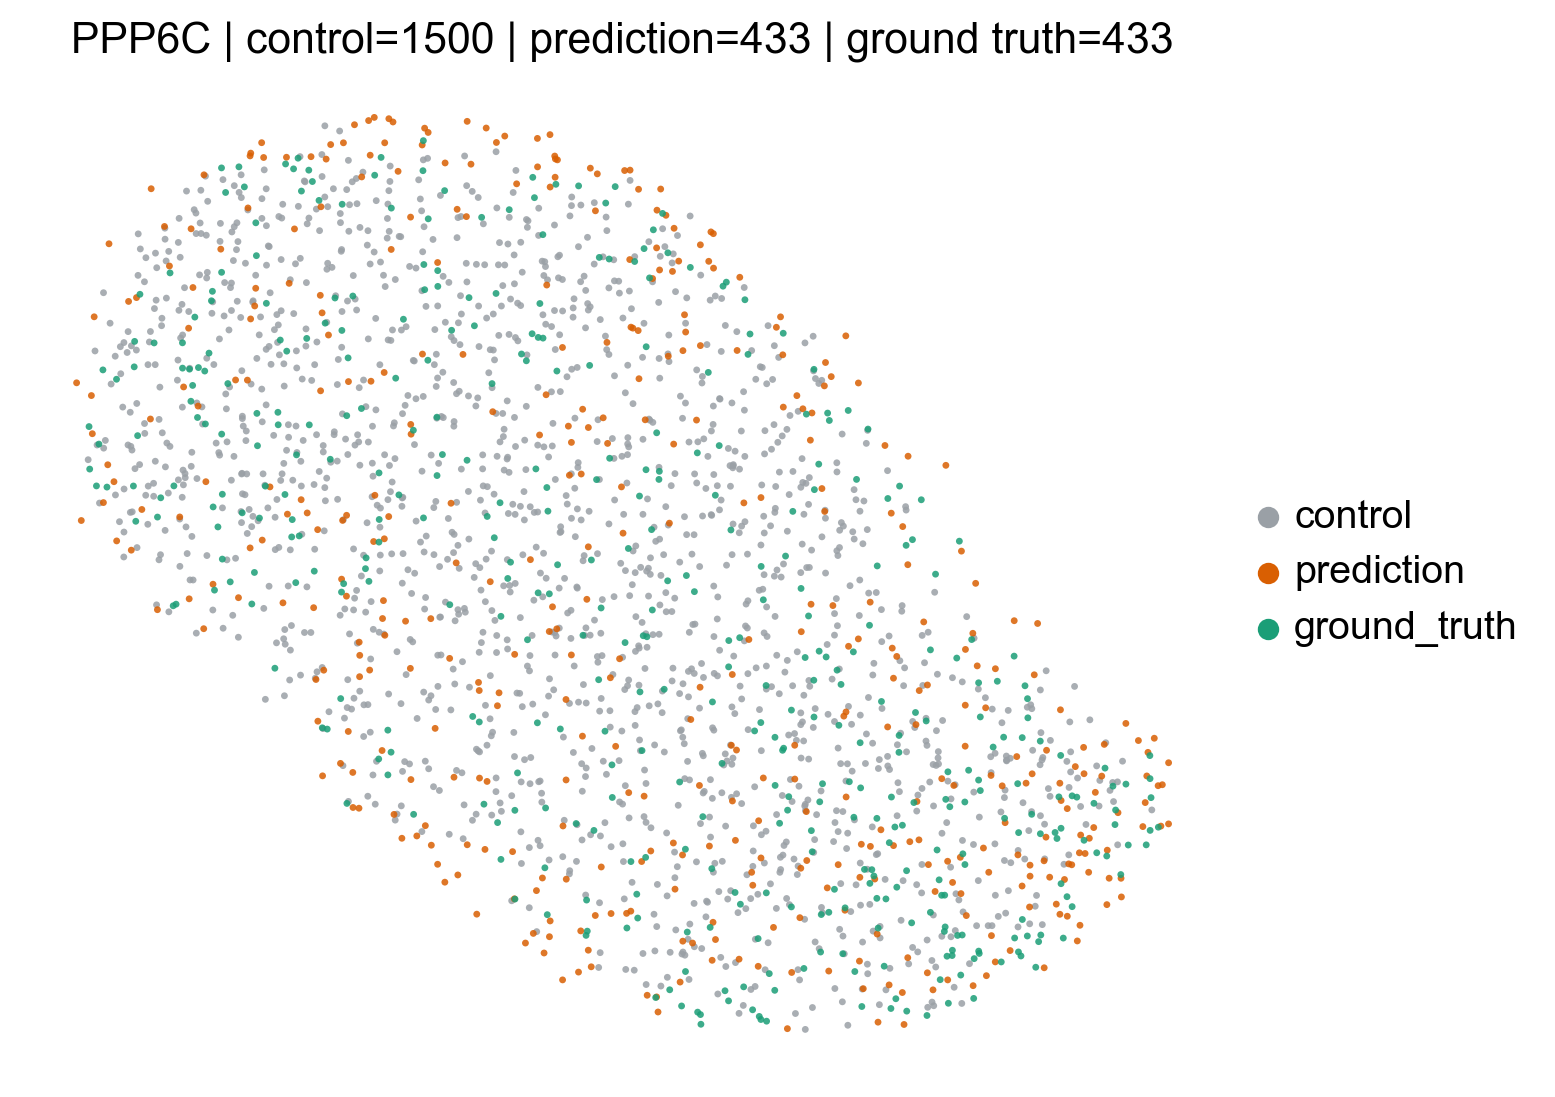

/home/zichong/fork/PerturbDiff/analyze/umap_plots/ZDHHC7_control_prediction_ground_truth_umap.png


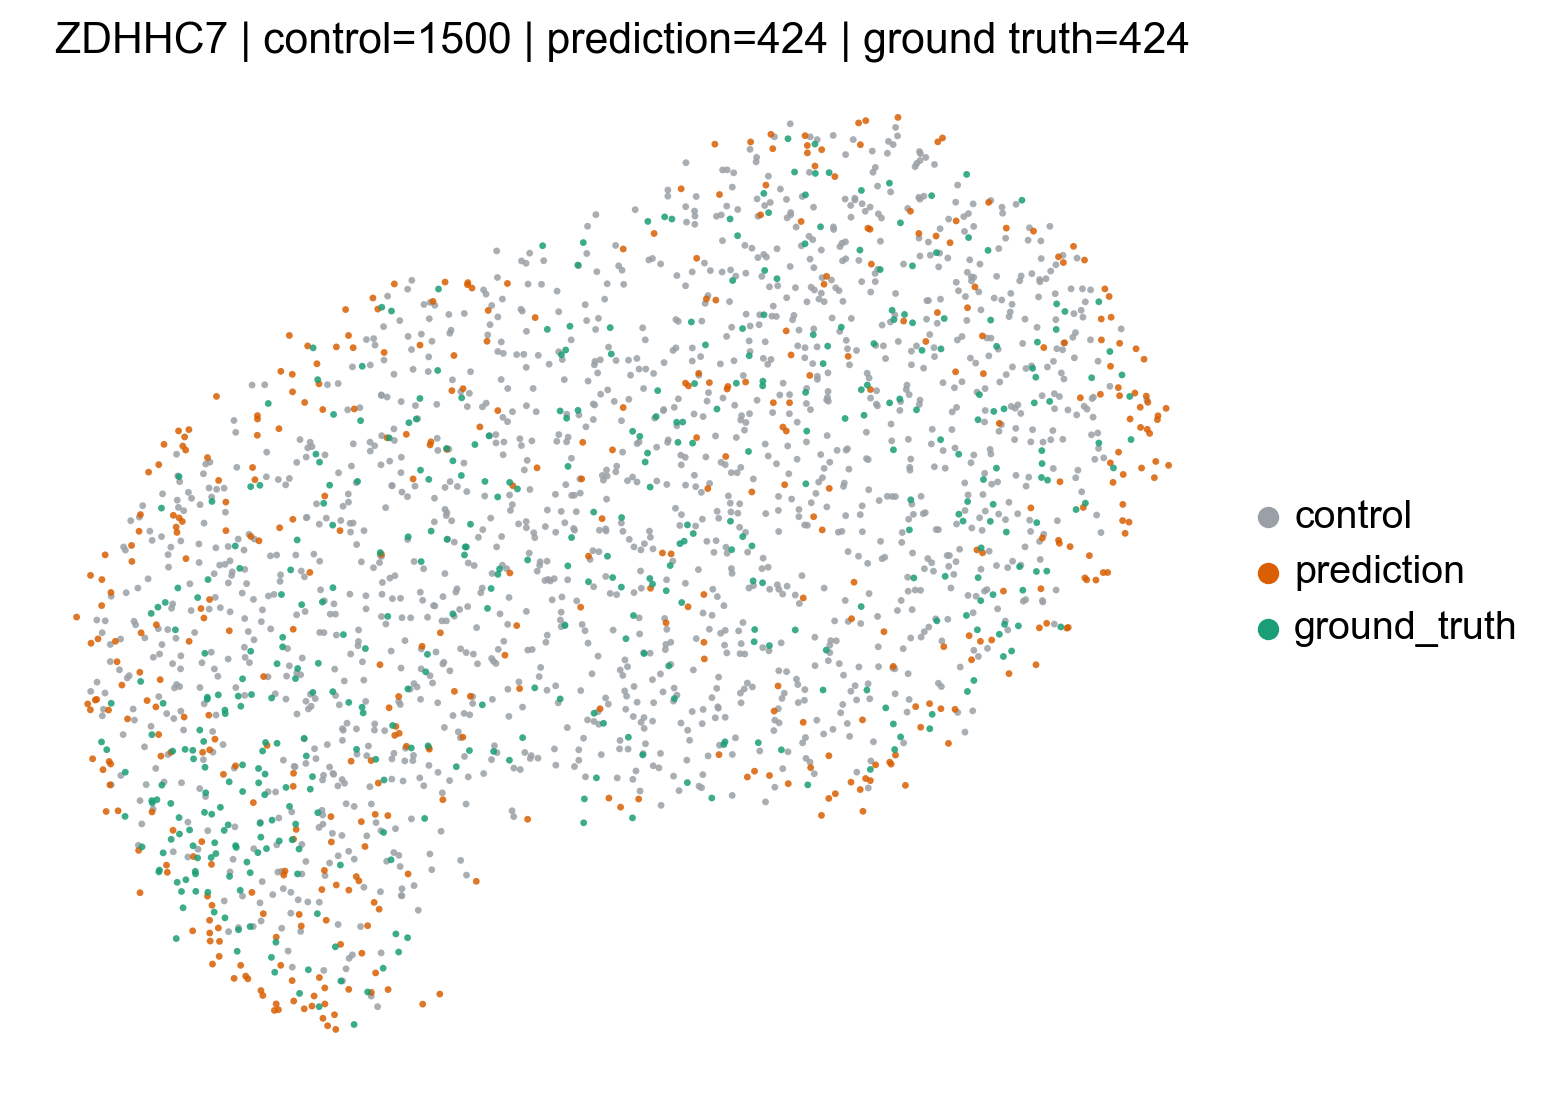

/home/zichong/fork/PerturbDiff/analyze/umap_plots/CCDC6_control_prediction_ground_truth_umap.png


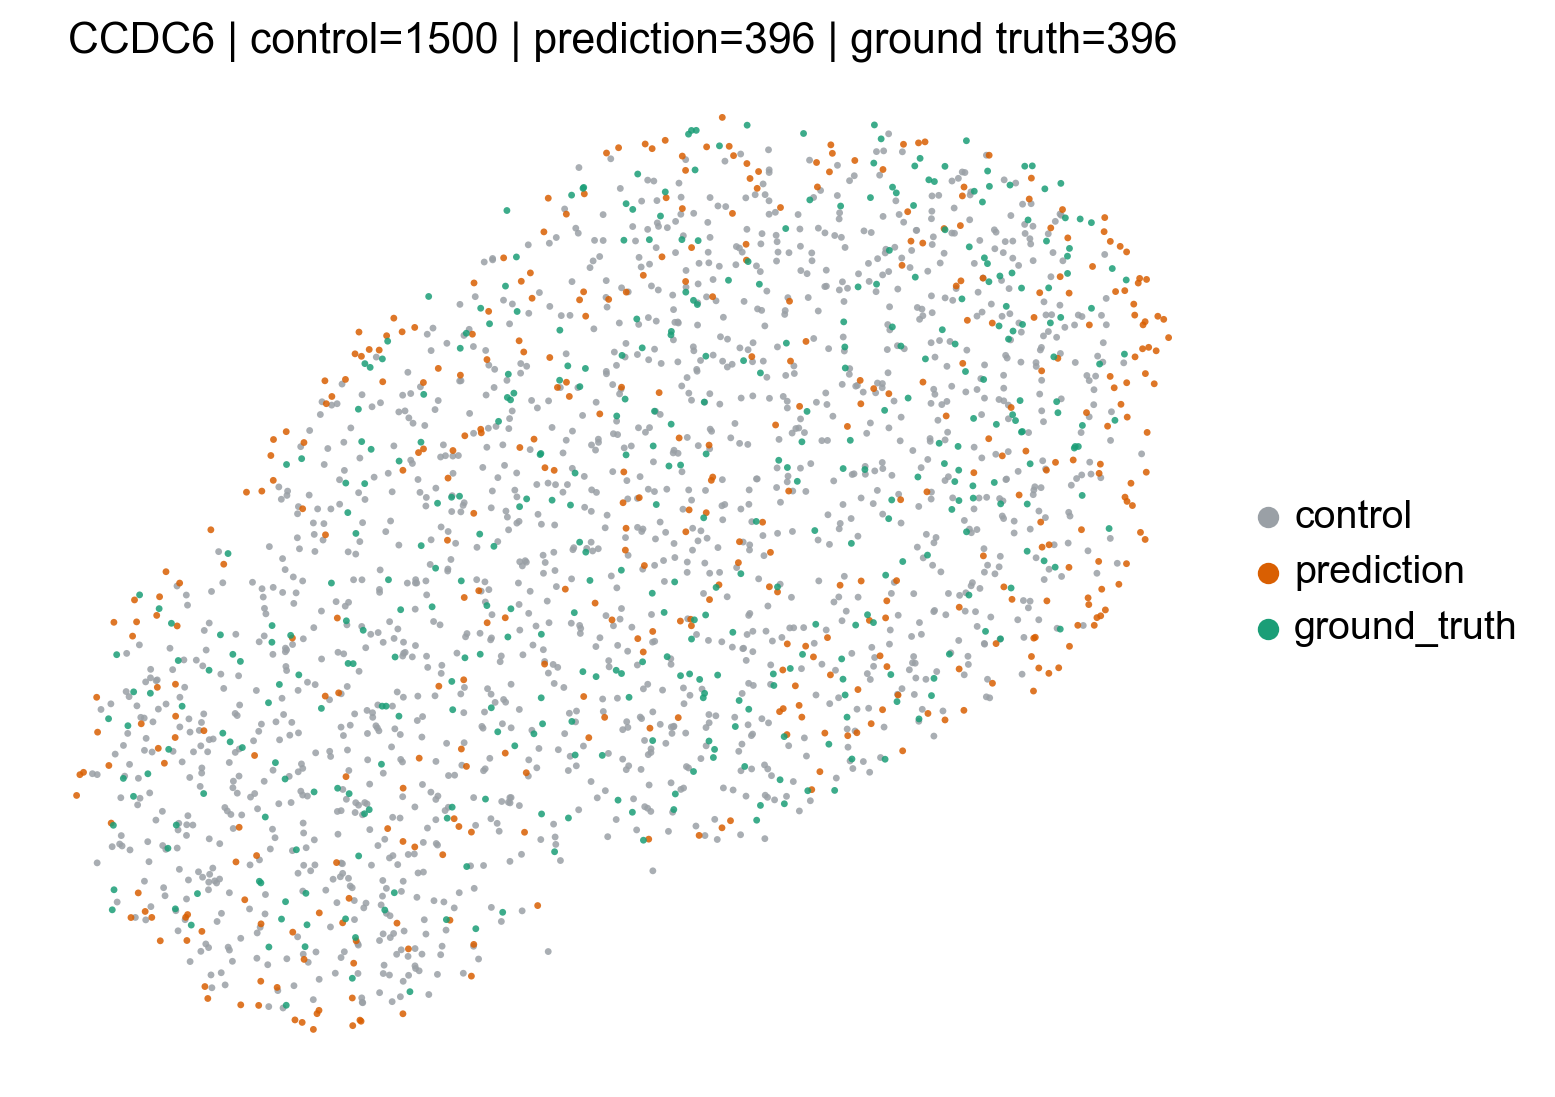

/home/zichong/fork/PerturbDiff/analyze/umap_plots/SART3_control_prediction_ground_truth_umap.png


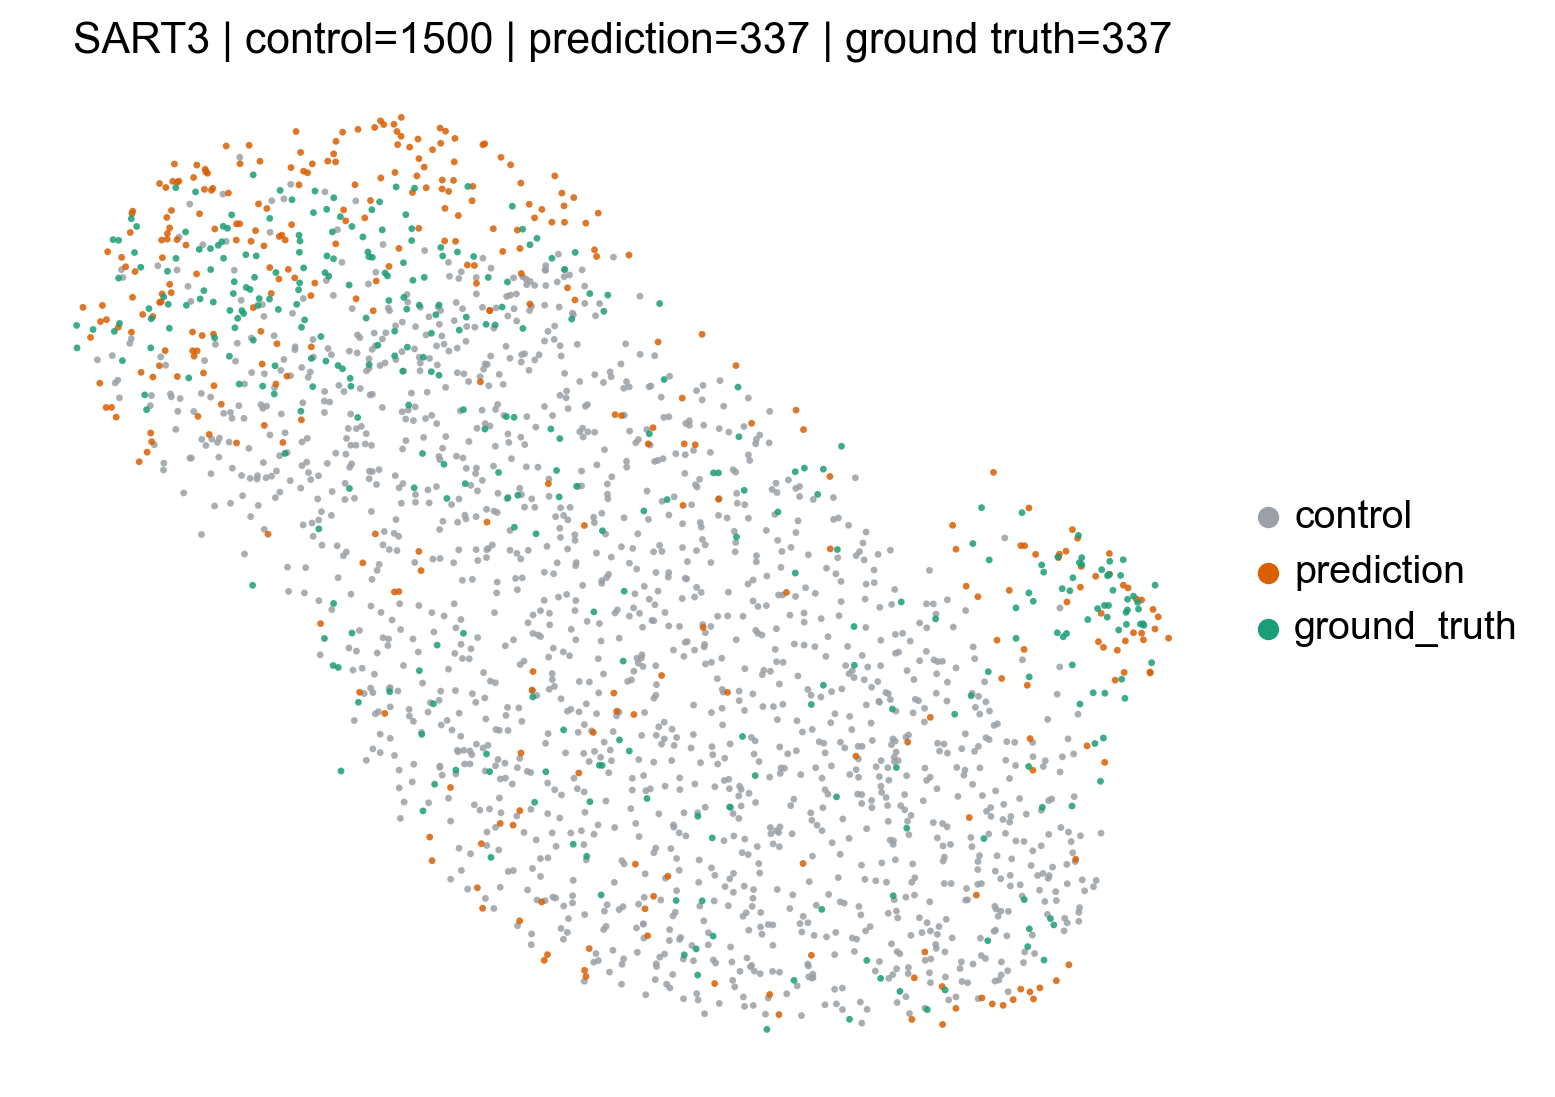

/home/zichong/fork/PerturbDiff/analyze/umap_plots/MRPL35_control_prediction_ground_truth_umap.png


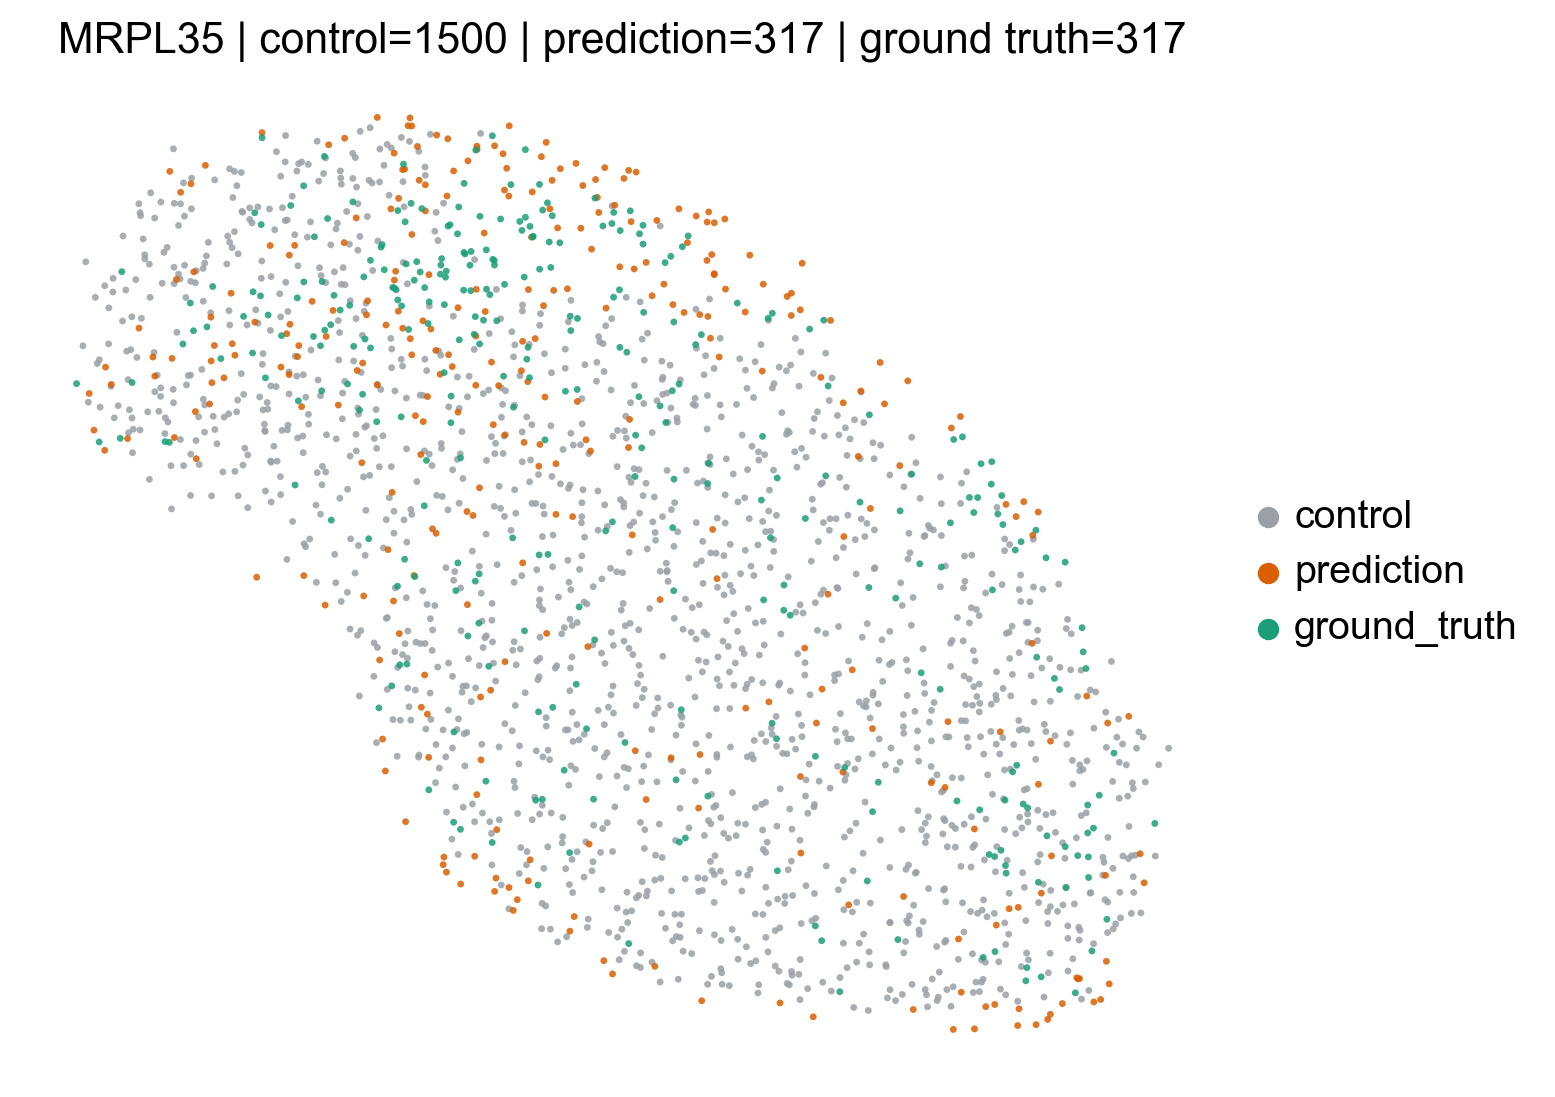

/home/zichong/fork/PerturbDiff/analyze/umap_plots/SLU7_control_prediction_ground_truth_umap.png


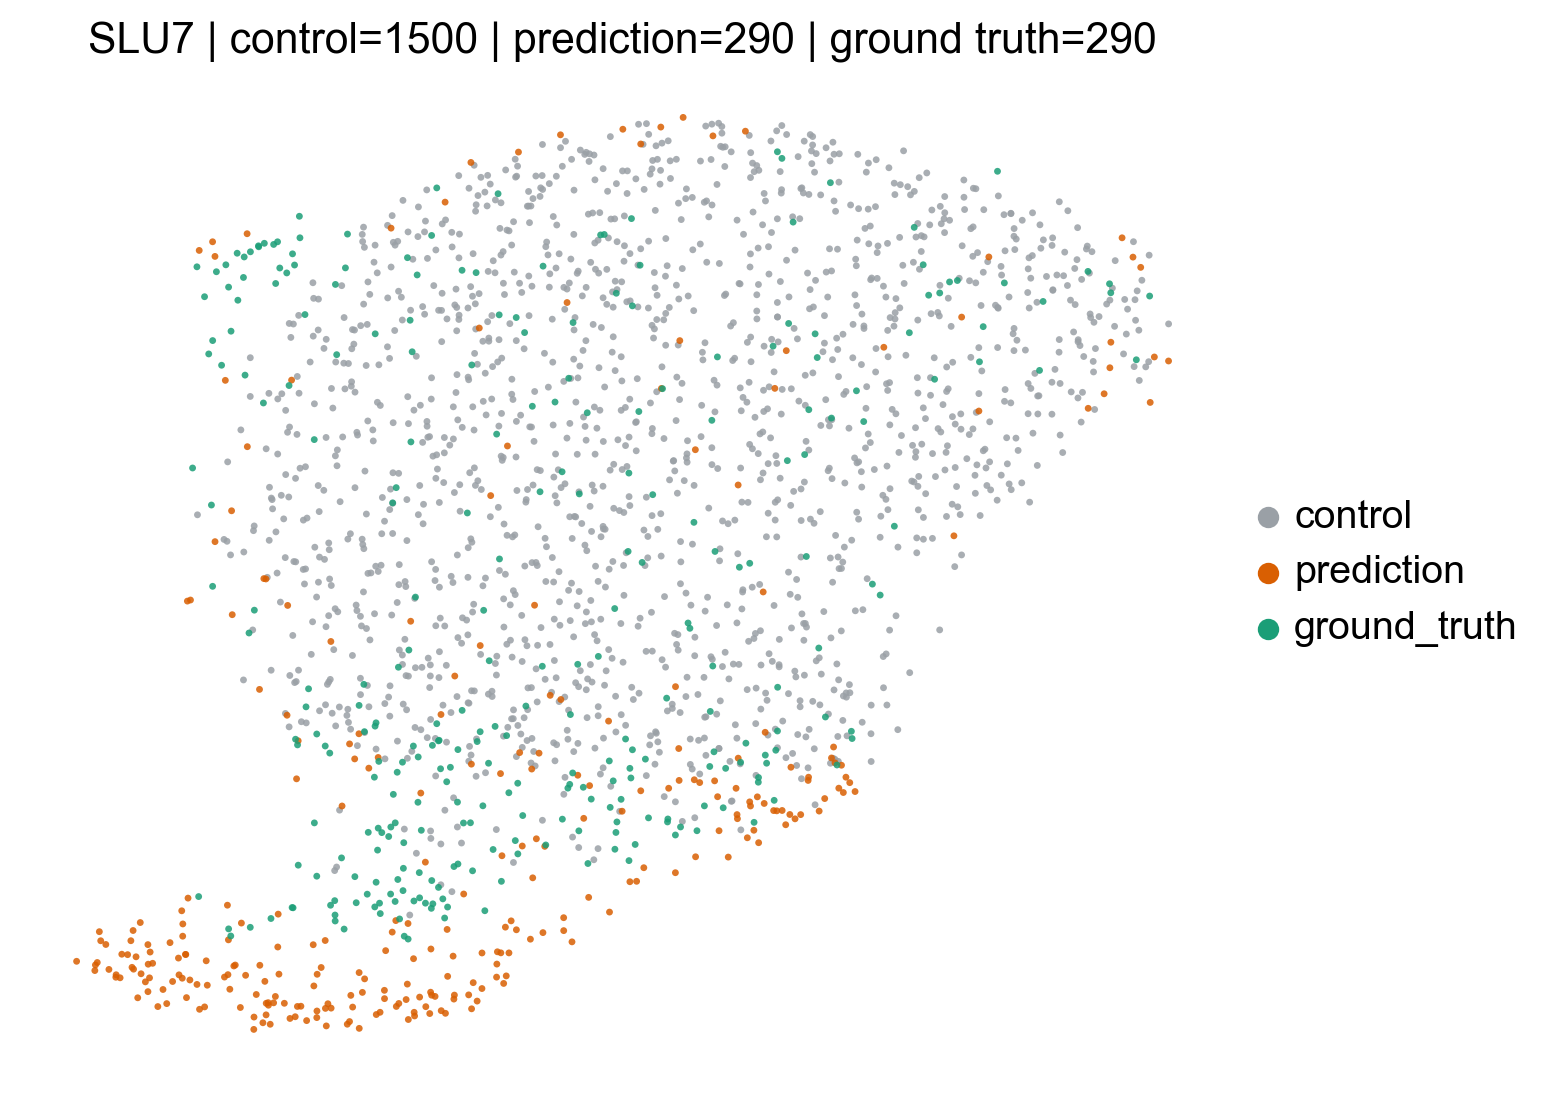

: 

: 

: 

: 

: 

In [ ]:
print(f"Saved summary to: {summary_path}")
for path in generated_paths:
    print(path)
    display(Image(filename=str(path), width=540))